In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew
import seaborn as sns


# Question 1

### 1. 
### ENTER EQs FROM PHOTOS

### 2.

In the log normal returns model we have:
$$r_t = \mu + \sigma \epsilon_t$$
where $r_t$ are the log returns, and $r_t \sim \mathcal{N}(\mu, \sigma^2)$. 

In this case, the skeness of the model is:
$$\frac{E[(r_t-E[r_t])^3]}{\sigma^3} = 0$$

And the kurtosis:
$$\frac{E[(r_t-E[r_t])^4]}{\sigma^4} = 3$$

This means that under the log normal returns model we are expecting normal returns, that is symmetric, and no fat tails to it.

In contrast, when modelling returns we expect a left tail that is more pronounced than the right tail (negative skewness). That is because, many investments with high Sharpe ratios have strongly negatively skewed returns. In addition, returns generally show fat tails, so the kurtosis should be greater than 3. This is because when talking about returns, it is more likely to have an extreme scenario (eg. crashes) than it would be predicted by normal distributions. 

Finally, the Bernoulli-normal mixture introduces jumps to the model. This jump means that shocks come periodically, without assuming a continous and smooth release of information.

For these reasons, the Bernoulli-normal mixture is potentially a better model of returns.

### 3.

In [56]:
np.random.seed(42)

In [93]:
def log_normal_returns(days, mu, sigma):
    rt = np.random.normal(mu, sigma, days)

    return rt

def bernoulli_normal_returns(days, mu, sigma, p, mu_J, sigma_J):
    delta = np.random.normal(0, 1, days)
    eps = np.random.normal(0, 1, days)

    Bt = np.random.binomial(1, p, days)

    Jt = Bt * (mu_J + sigma_J * delta)

    rt = mu + sigma * eps + Jt
    
    return rt

In [94]:
mu = 0.0004
sigma = 0.01
mu_J = -0.03
sigma_J = 0.04
p = 0.01

##### 50 years

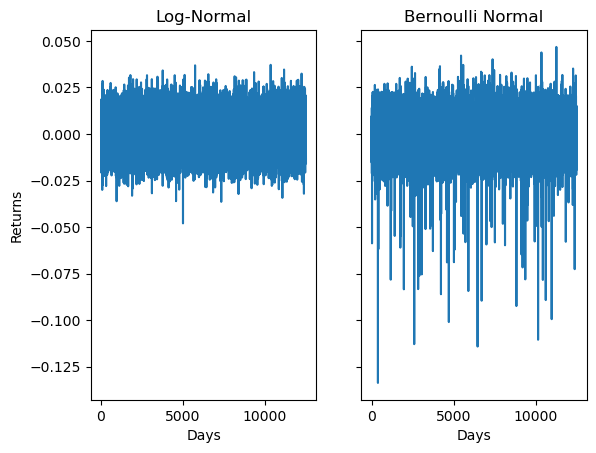

In [95]:
open_market_days = 250
years = 50
days = open_market_days * years

rt_log = log_normal_returns(days, mu, sigma)
rt_bernoulli = bernoulli_normal_returns(days, mu, sigma, p, mu_J, sigma_J)

fig, axs = plt.subplots(1, 2, sharey = True)

axs[0].set_ylabel('Returns')
axs[0].plot(rt_log)
axs[0].set_title('Log-Normal')
axs[0].set_xlabel('Days')
axs[1].plot(rt_bernoulli)
axs[1].set_title("Bernoulli Normal")
axs[1].set_xlabel('Days')

plt.show()

In [96]:
mean_log = np.mean(rt_log)
std_log = np.std(rt_log)
skew_log = skew(rt_log)
kurt_log = kurtosis(rt_log)

mean_bern = np.mean(rt_bernoulli)
std_bern = np.std(rt_bernoulli)
skew_bern = skew(rt_bernoulli)
kurt_bern = kurtosis(rt_bernoulli)

pd.DataFrame({'Log-Normal': [mean_log, std_log, skew_log, kurt_log],
                        'Bernoulli Normal': [mean_bern, std_bern, skew_bern, kurt_bern]}, 
                        index = ['Mean', 'STD','Skewness', 'Kurtosis'])

,Log-Normal,Bernoulli Normal
Mean,0.000389,0.000125
STD,0.009964,0.011114
Skewness,0.024110,-1.247913
Kurtosis,0.007122,9.553033


##### 10 years

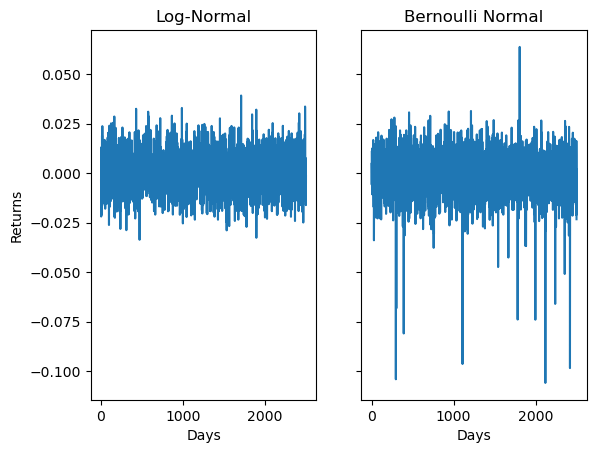

In [97]:
years = 10
days = open_market_days * years

rt_log = log_normal_returns(days, mu, sigma)
rt_bernoulli = bernoulli_normal_returns(days, mu, sigma, p, mu_J, sigma_J)

fig, axs = plt.subplots(1, 2, sharey = True)

axs[0].set_ylabel('Returns')
axs[0].plot(rt_log)
axs[0].set_title('Log-Normal')
axs[0].set_xlabel('Days')
axs[1].plot(rt_bernoulli)
axs[1].set_title("Bernoulli Normal")
axs[1].set_xlabel('Days')

plt.show()

In [98]:
mean_log = np.mean(rt_log)
std_log = np.std(rt_log)
skew_log = skew(rt_log)
kurt_log = kurtosis(rt_log)

mean_bern = np.mean(rt_bernoulli)
std_bern = np.std(rt_bernoulli)
skew_bern = skew(rt_bernoulli)
kurt_bern = kurtosis(rt_bernoulli)

pd.DataFrame({'Log-Normal': [mean_log, std_log, skew_log, kurt_log],
                        'Bernoulli Normal': [mean_bern, std_bern, skew_bern, kurt_bern]}, 
                        index = ['Mean', 'STD','Skewness', 'Kurtosis'])

,Log-Normal,Bernoulli Normal
Mean,0.000390,-0.000359
STD,0.010070,0.011652
Skewness,0.072653,-1.571877
Kurtosis,-0.034203,11.583148


### 4.

Here we want to find the t-stat of the sample mean. In this case, the t-stat is given by:
$$t = \frac{\bar{r}-E[r_t]}{\sqrt{Var(\bar{r})}}$$

where:
$$\bar{r} = \frac{1}{T}\sum_{t=1}^Tr_t = \frac{1}{T}\sum_{t=1}^T(\mu + \sigma \epsilon_t + B_t(\mu_J + \sigma_J \delta_t)) = \mu + \frac{1}{T}\sigma \sum_{t=1}^T\epsilon_t + \frac{1}{T}\sum_{t=1}^T B_t(\mu_J + \sigma_J \delta_t)$$

From Question 1:
$$E[r_t] = \mu + p\mu_J$$

and the variance is given by:

$$Var(\bar{r}) = Var(\frac{1}{T}\sum_{t=1}^Tr_t)= \frac{1}{T^2}Var(\sum_{t=1}^Tr_t)$$
since we are assuming no autocorrelation we get:
$$\frac{1}{T^2}Var(\sum_{t=1}^Tr_t) = \frac{1}{T^2}\sum_{t=1}^TVar(r_t) = \frac{1}{T}Var(r_t)$$

operate under the null hypothesis that the population mean is zero:
$$H_0: E[r_t] = 0$$
This means that:
$$E[r_t] = \mu + p\mu_J = 0 \Rightarrow \mu = -p\mu_J $$

In [138]:
def samples_bernoulli(days):
    mu = -p * mu_J
    rt = bernoulli_normal_returns(days, mu, sigma, p, mu_J, sigma_J)
    return rt

def t_statistic(rt):
    T = len(rt)
    mean = np.mean(rt)
    var_mean = np.var(rt)
    std_mean = np.sqrt(var_mean / T)
    
    return mean / std_mean, mean

def monte_carlo(N, days):
    t_stats = np.zeros(N)
    sample_means = np.zeros(N)

    for nn in range(N):
        rt = samples_bernoulli(days)
        t_stats[nn] = t_statistic(rt)[0]
        sample_means[nn] = t_statistic(rt)[1]

    return t_stats, sample_means
    

In [141]:
def distrib_plots(year):

    print(f'Distribution plots for {year} years.')
    
    stand_norm = np.random.normal(0, 1, N)
    sns.histplot(x=t_stats_dict[year], color='blue', label='t-stat')
    sns.histplot(x=stand_norm, color='red', alpha=0.3, label='Standard Normal')
    plt.title('Distribution of t-stat under $H_0$ vs. Standard Normal')
    plt.legend()
    plt.show()

    sns.histplot(x=sample_mean_dict[year], color='blue', label='Sample mean')
    plt.title('Distribution of sample means')
    plt.show()

Distribution plots for 0.1 year.


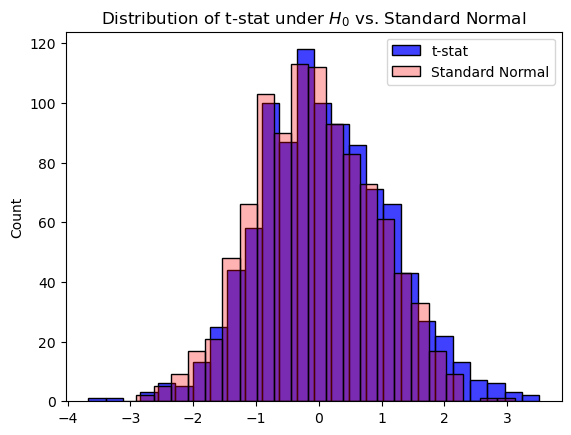

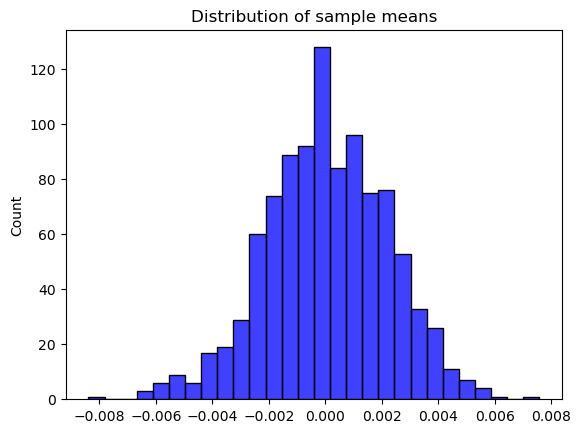

Distribution plots for 0.5 year.


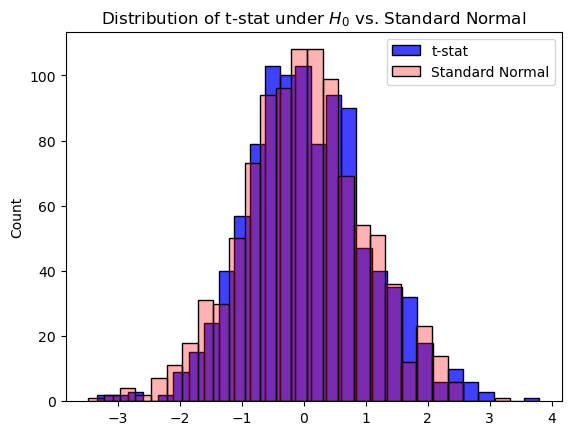

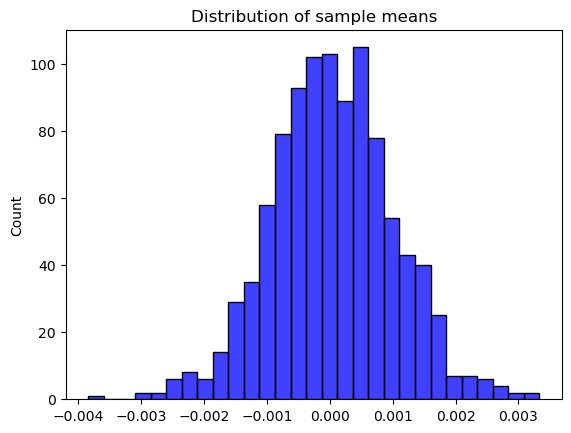

Distribution plots for 1 year.


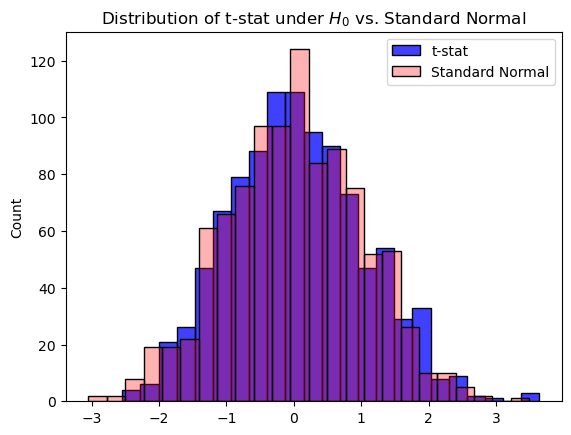

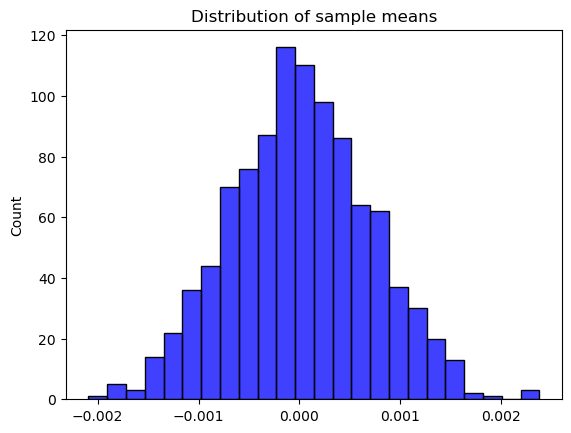

Distribution plots for 2 year.


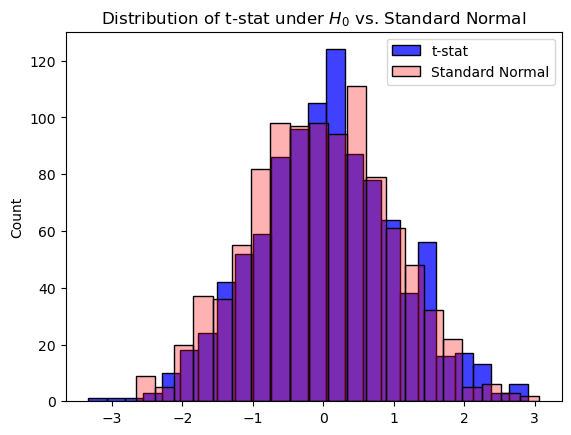

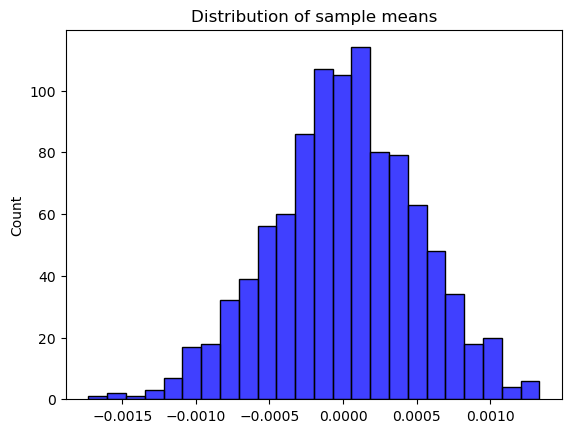

Distribution plots for 4 year.


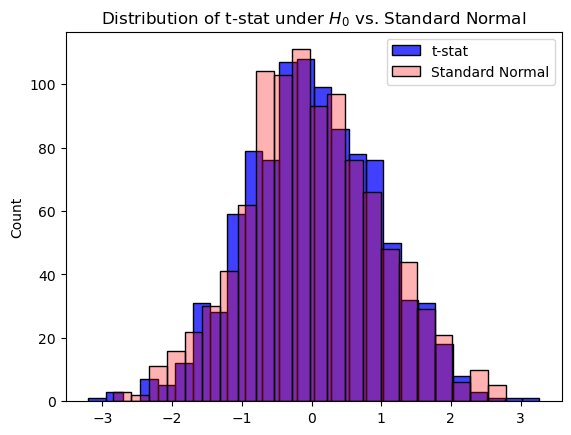

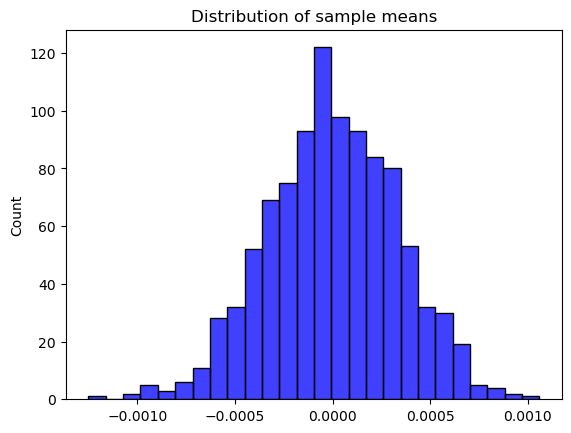

In [140]:
N = 1000 #samples
T = [0.1, 0.5, 1, 2, 4]
t_stats_dict = dict()
sample_mean_dict = dict()

for year in T:
    days = int(year * open_market_days)
    t_stats, sample_mean = monte_carlo(N, days)
    t_stats_dict[year] = t_stats
    sample_mean_dict[year] = sample_mean
    distrib_plots(year)

In [143]:
for year in T:
    print(f'The t-stat and sample mean moments for {year} years:')
    df = pd.DataFrame({'t-stat': [np.mean(t_stats_dict[year]), np.std(t_stats_dict[year]), skew(t_stats_dict[year]), kurtosis(t_stats_dict[year])],
                        'Sample Mean': [np.mean(sample_mean_dict[year]), np.std(sample_mean_dict[year]), skew(sample_mean_dict[year]), kurtosis(sample_mean_dict[year])]}, 
                        index = ['Mean', 'STD','Skewness', 'Kurtosis'])
    print(df)

The t-stat and sample mean moments for 0.1 years:
            t-stat  Sample Mean
Mean      0.088072     0.000057
STD       1.038773     0.002174
Skewness  0.165723    -0.145435
Kurtosis  0.126225     0.228858
The t-stat and sample mean moments for 0.5 years:
            t-stat  Sample Mean
Mean      0.080939     0.000044
STD       0.985387     0.000971
Skewness  0.179718     0.008637
Kurtosis  0.283185     0.370858
The t-stat and sample mean moments for 1 years:
            t-stat  Sample Mean
Mean      0.052076     0.000012
STD       1.002118     0.000698
Skewness  0.251435     0.060901
Kurtosis -0.096917    -0.141813
The t-stat and sample mean moments for 2 years:
            t-stat  Sample Mean
Mean      0.047001     0.000009
STD       0.996506     0.000495
Skewness  0.046217    -0.115568
Kurtosis -0.055796    -0.013232
The t-stat and sample mean moments for 4 years:
            t-stat  Sample Mean
Mean      0.022091     0.000001
STD       0.944194     0.000335
Skewness  0.001330  

# Question 2

In [146]:
import statsmodels.api as sm

### 1.

In [316]:
df = pd.read_csv('homework3data.csv')


In [317]:
df1 = df.copy()

In [318]:
df['rt+1'] = 12 * df.log_excess_ret.shift(1)
df.dropna(inplace = True)
Y = df['rt+1']
X = df.div_yld
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit(cov_type = "HC3")
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rt+1   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     5.218
Date:                Mon, 16 Feb 2026   Prob (F-statistic):             0.0226
Time:                        15:53:38   Log-Likelihood:                -557.43
No. Observations:                 719   AIC:                             1119.
Df Residuals:                     717   BIC:                             1128.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1984      0.064      3.098      0.002       0.073       0.324
div_yld       -5.2511      2.299     -2.284      0.022      -9.757      -0.745
==============================================================================
Omnibus:                      108.222   Durbin-Watson:                   1.850
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              304.555
Skew:                          -0.753   Prob(JB):                     7.36e-67
Kurtosis:                       5.810   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [319]:
dy_hat = results.params["div_yld"]
se_dy_hat = results.bse["div_yld"]
t_stat = dy_hat / se_dy_hat
print(f'The absolute value of the t-stat is {np.abs(t_stat):.2f}')

The absolute value of the t-stat is 2.28


In [320]:
results.t_test('div_yld')

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -5.2511      2.299     -2.284      0.022      -9.757      -0.745

Reject $H_0$ at the 5% level, but fail to do so at the 1%. There is statistical significance showcasing that divident yield can be used to estimate returns.

### 2.

### 3.

Here we are given:
$$r_{t+k,k} = r_{t+k} + r_{t+k-} + ... + r_{t+1}$$
We know that the monthly return model is:
$$r_{t+1} = \alpha + \beta dy_t + \epsilon_{t+1}$$

This means we can rewrite $r_{t+k,k}$ as:

$$r_{t+k,k} = \sum_{i=1}^k \alpha + \beta dy_{t+i-1} + \epsilon_{i+1} = k \alpha + \beta \sum_{i=1}^k dy_{t+i-1} + \sum_{i=1}^k \epsilon_{t+i} $$

From the $\sum_{i=1}^{k} \epsilon_{t+i}$ term we can see that at times $t=0$ and $t=1$, $r_{k,k}$ and $r_{k+1,k}$ will share k-1 shocks. This means that the process here is an MA(k-1) process.

Here we are given k = 12, so:
$$r_{t+12,12} = 12 \alpha + \beta \sum_{i=1}^{12} dy_{t+i-1} + \sum_{i=1}^{12} \epsilon_{t+i} $$
And therefore, the process is MA(11).



#### Code explanation

The dataset starts with January 1960. We want the divident yield at this time to predict the returns for the 12 months that follow, ie February 1960 - January 1961. 
For this date we will use the div_yld of the same index. For the $r_{t+12,12}$ value we will shift the log_excess_returns column by 12 indeces, to capture the next twelve months.

In addition, to capture the MA(11) process we set the and the maxlags to 11.


In [324]:
k = 12
df1['r_tk'] = df1.log_excess_ret.rolling(window = 12).sum().shift(-k)
df_rt = df1.dropna().copy()
Y = df_rt.r_tk
X = df_rt.div_yld
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit(cov_type = "HAC", cov_kwds = {'maxlags': 11})
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   r_tk   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     3.004
Date:                Mon, 16 Feb 2026   Prob (F-statistic):             0.0835
Time:                        15:54:51   Log-Likelihood:                 296.93
No. Observations:                 708   AIC:                            -589.9
Df Residuals:                     706   BIC:                            -580.7
Df Model:                           1                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0288      0.053     -0.541      0.588      -0.133       0.076
div_yld        2.7815      1.605      1.733      0.083      -0.364       5.927
==============================================================================
Omnibus:                      102.068   Durbin-Watson:                   0.138
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              153.771
Skew:                          -0.972   Prob(JB):                     4.06e-34
Kurtosis:                       4.196   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 11 lags and without small sample correction
"""

In [325]:
dy_hat = results.params["div_yld"]
se_dy_hat = results.bse["div_yld"]
t_stat = dy_hat / se_dy_hat
print(f'The absolute value of the t-stat is {np.abs(t_stat):.2f}')

The absolute value of the t-stat is 1.73


In [326]:
results.t_test('div_yld')

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             2.7815      1.605      1.733      0.083      -0.364       5.927

In [330]:
print(f'The R2 value is {results.rsquared:.2f}')

The R2 value is 0.03
